In [11]:
# 필요한 라이브러리 import
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import silhouette_score
# 주택 가격 데이터를 기반으로 회귀 모델을 학습하여 주택 가격을 예측 해야함
# 주택 가격 데이터 불러오기
df = pd.read_csv('./dataset/mall_customers.csv') #
print(df.head)



<bound method NDFrame.head of      CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0             1    Male   19                  15                      39
1             2    Male   21                  15                      81
2             3  Female   20                  16                       6
3             4  Female   23                  16                      77
4             5  Female   31                  17                      40
..          ...     ...  ...                 ...                     ...
195         196  Female   35                 120                      79
196         197  Female   45                 126                      28
197         198    Male   32                 126                      74
198         199    Male   32                 137                      18
199         200    Male   30                 137                      83

[200 rows x 5 columns]>


In [12]:
# 사용할 열 선택
features = ['Annual Income (k$)', 'Spending Score (1-100)']

X = df[features]

In [13]:
# 4. 스케일링
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)

(200, 2)


In [14]:
# 학습 테스트 데이터 분리 8:2
X_train, X_test = train_test_split(
    X_scaled,
    test_size=0.2,
    random_state=42
)

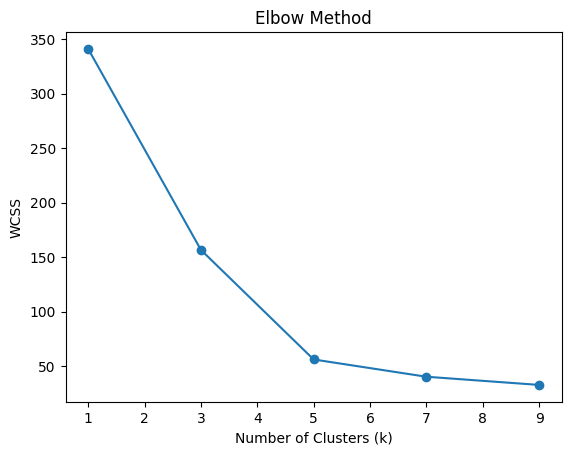

In [37]:
# 엘보우 기법
wcss = []
K_range = range(1, 10, 2)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_train)
    wcss.append(kmeans.inertia_)

plt.plot(K_range, wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.show()

In [ ]:
# 오차 제곱합의 감소폭이 급격한 지점 5를 최적의 K로 결정
optimal_k = 5

In [38]:
# 예측
train_labels = kmeans.predict(X_train)
test_labels = kmeans.predict(X_test)

In [39]:
# 실루엣 스코어 평가
score = silhouette_score(X_test, test_labels)
print("Silhouette Score: ",score)

Silhouette Score:  0.4780450857944161


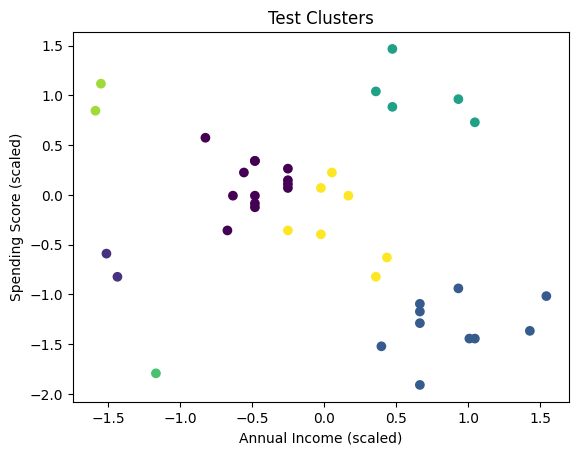

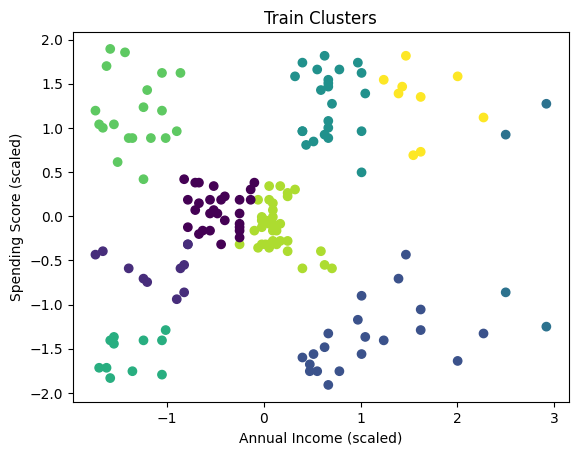

In [40]:
# 시각화 test
plt.scatter(X_test[:, 0], X_test[:, 1], c=test_labels)
plt.title('Test Clusters')
plt.xlabel('Annual Income (scaled)')
plt.ylabel('Spending Score (scaled)')
plt.show()

# 시각화 train
plt.scatter(X_train[:, 0], X_train[:, 1], c=train_labels)
plt.title('Train Clusters')
plt.xlabel('Annual Income (scaled)')
plt.ylabel('Spending Score (scaled)')
plt.show()

In [42]:
# 전체 데이터 클러스터 적용
df_scaled = pd.DataFrame(X_scaled, columns=features)
df_scaled['cluster'] = kmeans.predict(X_scaled)

In [45]:
cluster_summary = df_scaled.groupby('cluster').mean()
print('클러스터별 평균')
print(cluster_summary)

클러스터별 평균
         Annual Income (k$)  Spending Score (1-100)
cluster                                            
0                 -0.470098                0.087869
1                 -1.166458               -0.605019
2                  0.993932               -1.362637
3                  2.707739                0.021352
4                  0.667038                1.230366
5                 -1.373209               -1.576802
6                 -1.353670                1.158731
7                  0.129485               -0.154732
8                  1.619911                1.299228


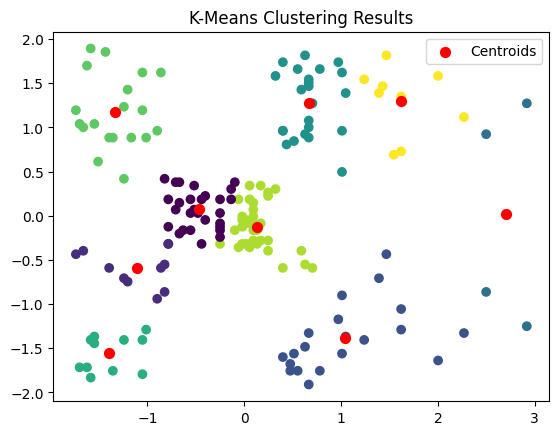

In [ ]:
plt.scatter(X_train[:, 0], X_train[:, 1], c=kmeans.labels_, cmap='viridis')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=50, c='red', marker='o', label='Centroids')
plt.title('K-Means Clustering Results')
plt.legend()

plt.show()
